In [10]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import matplotlib.lines as mlines
import h5py
from pathlib import Path

In [11]:
#importing data files
BASE_DIR = Path.cwd() #notebook directory
file_path = BASE_DIR / "scalar_results" / "results_FoM" / "massive" / "realization_0"

file_names = [
    "results_M1e+06_mu5.0_a0.9_ef0.0_T1.499999999941544_Lambda0.01_ScalarMass0.018_z0.1_der_order8.0.h5",
    "results_M1e+06_mu8.0_a0.9_ef0.0_T1.4999999999642455_Lambda0.01_ScalarMass0.018_z0.1_der_order8.0.h5",
    "results_M1e+06_mu10.0_a0.9_ef0.0_T1.499999999957003_Lambda0.01_ScalarMass0.018_z0.1_der_order8.0.h5",
]

npz_paths = [file_path / fn for fn in file_names]

In [12]:
#snr rescaling (not used):
def rescale_fisher_snr(fisher, snr_old, snr_new=150.0):
    scale = (snr_new / snr_old)**2
    return fisher * scale

#converting sigma from Lambda=d^2 to d 
def lambda_to_d_fisher(fisher, d_value, idx_lambda):
    """
    Fisher transformation when Lambda = d^2 → d
    """
    fisher_new = fisher.copy()

    factor = 2.0 * d_value

    # scala riga e colonna
    fisher_new[idx_lambda, :] *= factor
    fisher_new[:, idx_lambda] *= factor

    return fisher_new

def smart_float(x):
    if float(x).is_integer():
        return str(int(x))
    else:
        return str(x)    

#converting the scalar field mass to eV 
def mu_s_to_eV(mu_s):
    return (mu_s / 0.75) * 1e-16       

In [13]:
idx = [-2, -1]   # d , mu_s

all_samples = []
true_vals_all = []
labels_leg = []
results_table = []

for path in npz_paths:
    with h5py.File(path, "r") as f:
        fisher = f["gamma"][()]           # HDF5 read as numpy
        snr_old = f["snr"][()]
        params = f["fisher_params"][()]

    Lambda_val = params[idx[0]]
    mp_val = params[1]
    d_val = np.sqrt(Lambda_val)

    #fisher_scaled = rescale_fisher_snr(fisher, snr_old, snr_new) 
    fisher_d = lambda_to_d_fisher(fisher, d_val, idx_lambda=idx[0])

    cov_d = np.linalg.inv(fisher_d)
    cov_2d = cov_d[np.ix_(idx, idx)]
    
    sigma_d = np.sqrt(np.diag(cov_2d))[0]
    sigma_mu = np.sqrt(np.diag(cov_2d))[1]
    
    mu_s_val = params[-1]
    #print("mu_s_val=",mu_s_val)
    mu_s_ev_1e18 = mu_s_to_eV(mu_s_val) * 1e18
    
    rel_err_d = sigma_d * 100 / d_val
    rel_err_mu = sigma_mu * 100 / mu_s_val
    
    results_table.append({
        "mp": float(mp_val),
        "snr": float(snr_old),
        "mu_s_raw": float(mu_s_val),
        "mu_s_1e18_eV": float(mu_s_ev_1e18),
        "d": float(d_val),
        "sigma_d": float(sigma_d),
        "sigma_mu": float(sigma_mu),
        "rel_err_d": float(rel_err_d),
        "rel_err_mu": float(rel_err_mu),
        "filename": path.name
    })
    
    
    #print("σ_d, σ_mu_s =", sigma_d, sigma_mu)
    #print("σ_d/d %, σ_mu_s/mu_s % =", rel_err_d, rel_err_mu)

    mean_2d = np.array([d_val, params[idx[1]]])

    samples = np.random.multivariate_normal(
        mean=mean_2d,
        cov=cov_2d,
        size=120000
    )

    all_samples.append(samples)
    true_vals_all.append(mean_2d)
    labels_leg.append(rf"$m_p={smart_float(mp_val)}M_\odot$")


all_samples_ev = []
true_vals_all_ev = []

for samples, true_vals in zip(all_samples, true_vals_all):
    samples_ev = samples.copy()
    true_vals_ev = true_vals.copy()

    scale = 1e18
    samples_ev[:, 1] = mu_s_to_eV(samples[:, 1])
    samples_ev[:, 1] *= scale
    true_vals_ev[1] = mu_s_to_eV(true_vals[1])
    true_vals_ev[1] *= scale

    all_samples_ev.append(samples_ev)
    true_vals_all_ev.append(true_vals_ev)


results_table = sorted(results_table, key=lambda x: (x["mp"], x["mu_s_1e18_eV"]))

for row in results_table:
    print(
        f"m_p = {row['mp']:>4.0f} | "
        f"SNR = {row['snr']:>4.0f} | "
        f"mu_s = {row['mu_s_1e18_eV']:>4.1f} (1e-18 eV) | "
        f"σ_d/d = {row['rel_err_d']:>6.1f}% | "
        f"σ_mu/μ = {row['rel_err_mu']:>6.1f}%"
        )

m_p =    5 | SNR =   95 | mu_s =  2.4 (1e-18 eV) | σ_d/d =   52.3% | σ_mu/μ =  100.2%
m_p =    8 | SNR =  131 | mu_s =  2.4 (1e-18 eV) | σ_d/d =   26.1% | σ_mu/μ =   29.8%
m_p =   10 | SNR =  151 | mu_s =  2.4 (1e-18 eV) | σ_d/d =   19.4% | σ_mu/μ =   16.5%


In [14]:
## GENERATE MACROS

def number_to_word(x):
    mapping = {
        0: "zero",
        1: "one",
        2: "two",
        3: "three",
        4: "four",
        5: "five",
        6: "six",
        7: "seven",
        8: "eight",
        9: "nine",
        10: "ten",
    }

    if abs(x - round(x)) < 1e-9:
        return mapping.get(int(round(x)), f"n{int(x)}")

    # numbers like 2.4 -> TwoFour
    s = f"{x:.1f}"
    a, b = s.split(".")
    return mapping[int(a)].capitalize() + mapping[int(b)].capitalize()

def make_macro_names(row):
    mp = number_to_word(row["mp"])
    mu = number_to_word(row["mu_s_1e18_eV"])

    macro_d = f"\\Mp{mp}Ms{mu}RelErrD"
    macro_mu = f"\\Mp{mp}Ms{mu}RelErrMus"

    return macro_d, macro_mu

def generate_macros(results, ndigits=0):
    lines = []

    for row in results:
        macro_d, macro_mu = make_macro_names(row)

        val_d = f"{row['rel_err_d']:.{ndigits}f}"
        val_mu = f"{row['rel_err_mu']:.{ndigits}f}"

        lines.append(f"\\newcommand{{{macro_d}}}{{\\ensuremath{{{val_d}}}\\%}}")
        lines.append(f"\\newcommand{{{macro_mu}}}{{\\ensuremath{{{val_mu}}}\\%}}")

    return "\n".join(lines)  

macros_text = generate_macros(results_table, ndigits=0)

print("\n=== LATEX MACROS ===\n")
print(macros_text)


=== LATEX MACROS ===

\newcommand{\MpfiveMsTwoFourRelErrD}{\ensuremath{52}\%}
\newcommand{\MpfiveMsTwoFourRelErrMus}{\ensuremath{100}\%}
\newcommand{\MpeightMsTwoFourRelErrD}{\ensuremath{26}\%}
\newcommand{\MpeightMsTwoFourRelErrMus}{\ensuremath{30}\%}
\newcommand{\MptenMsTwoFourRelErrD}{\ensuremath{19}\%}
\newcommand{\MptenMsTwoFourRelErrMus}{\ensuremath{16}\%}


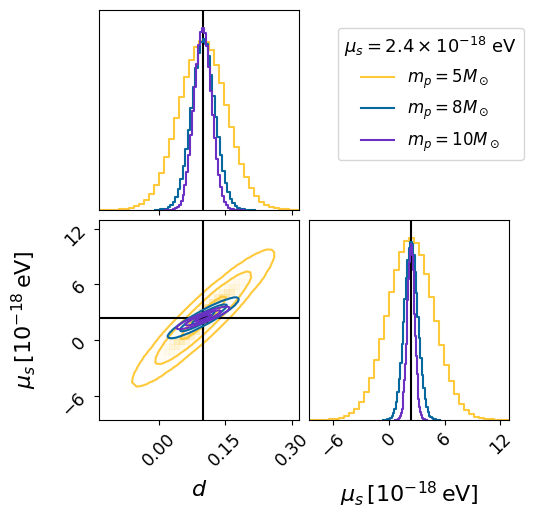

In [17]:
names_2d = [r"$d$", r"$\mu_s\, [10^{-18}\,\mathrm{eV}]$"]

corner_kwargs = dict(
    plot_datapoints=False,
    smooth1d=True,
    labels=names_2d,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9/2)),
    label_kwargs=dict(fontsize=16),
    max_n_ticks=4,
    show_titles=False,
    smooth=True,
    labelpad=0.,
)

colors = ["#ffc93c", "#07689f", "#6930c3", "navy"]

figure = corner.corner(
    all_samples_ev[0],
    bins=40,
    color=colors[0],
    **corner_kwargs
)

N_params = 2
axes = np.array(figure.axes).reshape((N_params, N_params))

# blac lines (true values)
for i in range(N_params):
    axes[i, i].axvline(true_vals_all_ev[0][i], color="k")

for yi in range(N_params):
    for xi in range(yi):
        ax = axes[yi, xi]
        ax.axhline(true_vals_all_ev[0][yi], color="k")
        ax.axvline(true_vals_all_ev[0][xi], color="k")
        ax.plot(true_vals_all_ev[0][xi], true_vals_all_ev[0][yi], "sk")

for i in range(1, len(all_samples_ev)):
    corner.corner(
        all_samples_ev[i],
        fig=figure,
        bins=40,
        color=colors[i],
        **corner_kwargs
    )

# tick size
for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=12.5)

# legend
handles = [
    mlines.Line2D([], [], color=colors[i], label=labels_leg[i])
    for i in range(len(labels_leg))
]

plt.legend(
    handles=handles,
    fontsize=12,
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(0.1, 2.), 
    title=r"$\mu_s = 2.4\times10^{-18}$ eV",
    title_fontsize=13
)

figure.savefig("figures/corner_plot_massive_0.018.pdf", bbox_inches="tight")

plt.show()

In [18]:
BASE_DIR = Path.cwd() #notebook directory
file_path = BASE_DIR / "scalar_results" / "results_FoM" / "massive" / "realization_0"

file_names = [
    "results_M1e+06_mu5.0_a0.9_ef0.0_T1.4999999999422062_Lambda0.01_ScalarMass0.036_z0.1_der_order8.0.h5",
    "results_M1e+06_mu8.0_a0.9_ef0.0_T1.4999999999643807_Lambda0.01_ScalarMass0.036_z0.1_der_order8.0.h5",
    "results_M1e+06_mu10.0_a0.9_ef0.0_T1.4999999999562517_Lambda0.01_ScalarMass0.036_z0.1_der_order8.0.h5",
]

npz_paths = [file_path / fn for fn in file_names]

In [19]:
idx = [-2, -1]   # d , mu_s

all_samples = []
true_vals_all = []
labels_leg = []
results_table = []

for path in npz_paths:
    with h5py.File(path, "r") as f:
        fisher = f["gamma"][()]           # HDF5 read as numpy
        snr_old = f["snr"][()]
        params = f["fisher_params"][()]

    Lambda_val = params[idx[0]]
    mp_val = params[1]
    d_val = np.sqrt(Lambda_val)

    #fisher_scaled = rescale_fisher_snr(fisher, snr_old, snr_new) 
    fisher_d = lambda_to_d_fisher(fisher, d_val, idx_lambda=idx[0])

    cov_d = np.linalg.inv(fisher_d)
    cov_2d = cov_d[np.ix_(idx, idx)]
    
    sigma_d = np.sqrt(np.diag(cov_2d))[0]
    sigma_mu = np.sqrt(np.diag(cov_2d))[1]
    
    mu_s_val = params[-1]
    #print("mu_s_val=",mu_s_val)
    mu_s_ev_1e18 = mu_s_to_eV(mu_s_val) * 1e18
    
    rel_err_d = sigma_d * 100 / d_val
    rel_err_mu = sigma_mu * 100 / mu_s_val
    
    results_table.append({
        "mp": float(mp_val),
        "snr": float(snr_old),
        "mu_s_raw": float(mu_s_val),
        "mu_s_1e18_eV": float(mu_s_ev_1e18),
        "d": float(d_val),
        "sigma_d": float(sigma_d),
        "sigma_mu": float(sigma_mu),
        "rel_err_d": float(rel_err_d),
        "rel_err_mu": float(rel_err_mu),
        "filename": path.name
    })

    mean_2d = np.array([d_val, params[idx[1]]])

    samples = np.random.multivariate_normal(
        mean=mean_2d,
        cov=cov_2d,
        size=120000
    )

    all_samples.append(samples)
    true_vals_all.append(mean_2d)
    labels_leg.append(rf"$m_p={smart_float(mp_val)}M_\odot$")


all_samples_ev = []
true_vals_all_ev = []

for samples, true_vals in zip(all_samples, true_vals_all):
    samples_ev = samples.copy()
    true_vals_ev = true_vals.copy()

    scale = 1e18
    samples_ev[:, 1] = mu_s_to_eV(samples[:, 1])
    samples_ev[:, 1] *= scale
    true_vals_ev[1] = mu_s_to_eV(true_vals[1])
    true_vals_ev[1] *= scale

    all_samples_ev.append(samples_ev)
    true_vals_all_ev.append(true_vals_ev)

results_table = sorted(results_table, key=lambda x: (x["mp"], x["mu_s_1e18_eV"]))

for row in results_table:
    print(
        f"m_p = {row['mp']:>4.0f} | "
        f"SNR = {row['snr']:>4.0f} | "
        f"mu_s = {row['mu_s_1e18_eV']:>4.1f} (1e-18 eV) | "
        f"σ_d/d = {row['rel_err_d']:>6.1f}% | "
        f"σ_mu/μ = {row['rel_err_mu']:>6.1f}%"
        )

m_p =    5 | SNR =   95 | mu_s =  4.8 (1e-18 eV) | σ_d/d =   52.4% | σ_mu/μ =   14.5%
m_p =    8 | SNR =  131 | mu_s =  4.8 (1e-18 eV) | σ_d/d =   23.6% | σ_mu/μ =   12.7%
m_p =   10 | SNR =  151 | mu_s =  4.8 (1e-18 eV) | σ_d/d =   15.0% | σ_mu/μ =   10.3%


In [20]:
## GENERATE MACROS

def number_to_word(x):
    mapping = {
        0: "zero",
        1: "one",
        2: "two",
        3: "three",
        4: "four",
        5: "five",
        6: "six",
        7: "seven",
        8: "eight",
        9: "nine",
        10: "ten",
    }

    if abs(x - round(x)) < 1e-9:
        return mapping.get(int(round(x)), f"n{int(x)}")

    # numbers like 2.4 -> TwoFour
    s = f"{x:.1f}"
    a, b = s.split(".")
    return mapping[int(a)].capitalize() + mapping[int(b)].capitalize()

def make_macro_names(row):
    mp = number_to_word(row["mp"])
    mu = number_to_word(row["mu_s_1e18_eV"])

    macro_d = f"\\Mp{mp}Ms{mu}RelErrD"
    macro_mu = f"\\Mp{mp}Ms{mu}RelErrMus"

    return macro_d, macro_mu

def generate_macros(results, ndigits=0):
    lines = []

    for row in results:
        macro_d, macro_mu = make_macro_names(row)

        val_d = f"{row['rel_err_d']:.{ndigits}f}"
        val_mu = f"{row['rel_err_mu']:.{ndigits}f}"

        lines.append(f"\\newcommand{{{macro_d}}}{{\\ensuremath{{{val_d}}}\\%}}")
        lines.append(f"\\newcommand{{{macro_mu}}}{{\\ensuremath{{{val_mu}}}\\%}}")

    return "\n".join(lines)  

macros_text = generate_macros(results_table, ndigits=0)

print("\n=== LATEX MACROS ===\n")
print(macros_text)


=== LATEX MACROS ===

\newcommand{\MpfiveMsFourEightRelErrD}{\ensuremath{52}\%}
\newcommand{\MpfiveMsFourEightRelErrMus}{\ensuremath{14}\%}
\newcommand{\MpeightMsFourEightRelErrD}{\ensuremath{24}\%}
\newcommand{\MpeightMsFourEightRelErrMus}{\ensuremath{13}\%}
\newcommand{\MptenMsFourEightRelErrD}{\ensuremath{15}\%}
\newcommand{\MptenMsFourEightRelErrMus}{\ensuremath{10}\%}


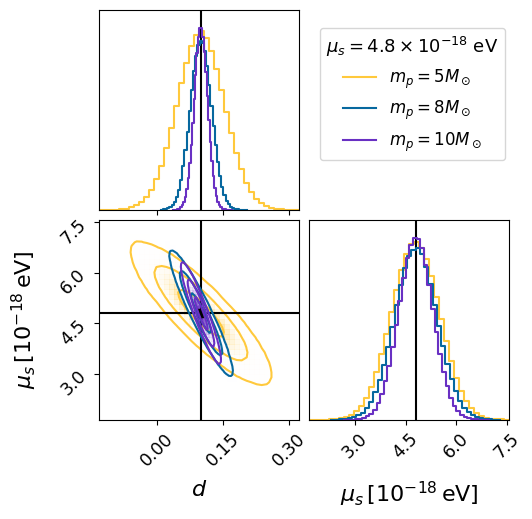

In [21]:
names_2d = [r"$d$", r"$\mu_s\, [10^{-18}\,\mathrm{eV}]$"]

corner_kwargs = dict(
    plot_datapoints=False,
    smooth1d=True,
    labels=names_2d,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9/2)),
    label_kwargs=dict(fontsize=16),
    max_n_ticks=4,
    show_titles=False,
    smooth=True,
    labelpad=0.,
    spacing = 1.5
)

colors = ["#ffc93c", "#07689f", "#6930c3", "navy"]

figure = corner.corner(
    all_samples_ev[0],
    bins=40,
    color=colors[0],
    **corner_kwargs
)

N_params = 2
axes = np.array(figure.axes).reshape((N_params, N_params))

for i in range(N_params):
    axes[i, i].axvline(true_vals_all_ev[0][i], color="k")

for yi in range(N_params):
    for xi in range(yi):
        ax = axes[yi, xi]
        ax.axhline(true_vals_all_ev[0][yi], color="k")
        ax.axvline(true_vals_all_ev[0][xi], color="k")
        ax.plot(true_vals_all_ev[0][xi], true_vals_all_ev[0][yi], "sk")

for i in range(1, len(all_samples_ev)):
    corner.corner(
        all_samples_ev[i],
        fig=figure,
        bins=40,
        color=colors[i],
        **corner_kwargs
    )

# tick size
for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=12.5)

handles = [
    mlines.Line2D([], [], color=colors[i], label=labels_leg[i])
    for i in range(len(labels_leg))
]

plt.legend(
    handles=handles,
    fontsize=12,
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(0.01, 2.),
    title=r"$\mu_s = 4.8\times10^{-18}$ eV",
    title_fontsize=13
)

figure.savefig("figures/corner_plot_massive_0.036.pdf", bbox_inches="tight")

plt.show()